In [ ]:
"""

Gemini API Free Tier Limits

Model	                Requests Per Minute (RPM)	    Requests Per Day
Gemini 2.5 Flash	    10	                            250
Gemini 2.5 Flash-Lite	15	                            1,000
Gemini 2.5 Pro	        5	                            100

"""

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

In [5]:
# import langchain.chat_models as cm

from langchain.chat_models import init_chat_model

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0.0)

In [6]:
# testing the connection

response = llm.invoke(["What is the capital of France?"])
print(response.content)

The capital of France is **Paris**.


In [7]:
# defining the agent state

from typing_extensions import TypedDict, List

class State(TypedDict):
    question: str
    answer: str
    history: List[str]


In [8]:
# defining the node functions for workflow

def classify(state: State) -> str:

    # this is a function where we use to classify the questions into a category
    # and manage routing of the question to the right agent

    # for now, this is just a placeholder function

    return {"question": state["question"]}

def generate(state: State) -> str:

    # this is a function where we use to generate the answer to the question
    # using the llm

    context = "\n".join(state.get("history", []))

    prompt = f"""

    You are a conversational AI Assistant. Use the context history to reply naturally, and keep everything concise.

    context:    {context}

    question:   {state["question"]}

    """

    response = llm.invoke([{
        "role" : "user",
        "content" : prompt,
        }])
    
    return {"answer" : response.content}

def refine(state):

    # this is just a placeholder refinement for now, we might shorten answers/improve grammar/format or anything here.
    
    refined = state["answer"] + "\n\n [refined for clarity]"

    history = state.get("history", [])

    history.append(f"Q: {state["question"]} \nA: {refined}")

    return {"answer" : refined, "history" : history}

In [ ]:
# building LangGraph Workflow

from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence([classify, generate, refine])
graph_builder.add_edge(START, "classify")

graph = graph_builder.compile()

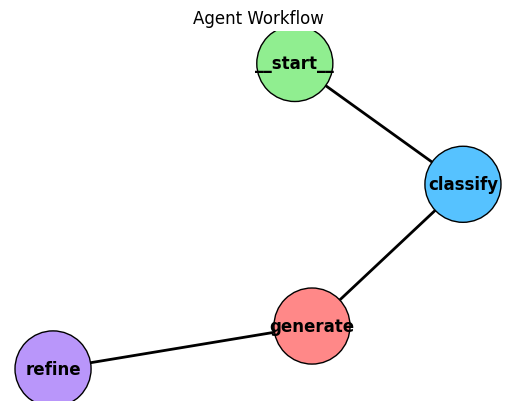

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_langgraph(graph_builder):

    G = nx.DiGraph()

    for node in graph_builder.nodes:
        G.add_node(node)

    for u, v in graph_builder.edges:
        G.add_edge(u, v)

    pos = nx.spring_layout(G, seed=42, k=1.2)
    colors = ["#56c2ff", "#ff8888", "#b996fa", "#90ee90"]
    sizes = [3000] * len(G.nodes)

    nx.draw_networkx_nodes(
        G, 
        pos, 
        node_color=colors[:len(G.nodes)], 
        node_size=sizes,
        edgecolors="black"
    )

    nx.draw_networkx_edges(G, pos, arrows=True, width=2)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

    plt.title("Agent Workflow")
    plt.axis("off")
    plt.show()

visualize_langgraph(graph_builder)

In [ ]:

state = {
    "question" : "",
    "answer" : "",
    "history" : [],
}

print("AI Agent with memory is ready! Type 'exit' to quit.\n")

while True:

    question = input("Ask a question: ")

    if question.lower() in ("exit", "quit"):
        break

    state["question"] = question
    response = graph.invoke(state)
    state.update(response)

    print("\nAnswer:\n", response.get("answer", "answer is not generated"))
    print("\n" + "=" * 60 + "\n")

AI Agent with memory is ready! Type 'exit' to quit.


Answer:
 I'm ready to help! What's on your mind?

 [refined for clarity]



Answer:
 I'm ready to help! What's on your mind?

 [refined for clarity]



Answer:
 I'm ready to help! What's on your mind?

 [refined for clarity]



Answer:
 I'm ready to help! What's on your mind?

 [refined for clarity]



Answer:
 I'm ready to help! What's on your mind?

 [refined for clarity]



Answer:
 I'm ready to help! What's on your mind?

 [refined for clarity]


